In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [56]:
data = pd.read_csv("data.csv")
data = data[data.delay_k == 10]
data = data[data.target == "proprio"]
data = data[data.condition.isin(["forward_model", "pg_forward_model"])]

In [57]:
layers = [
    (-1, "input\n(delayed+\nefference)", "input::delayed_plus_efference"),
    (1, "pred 1", "layer::3/action/1/predictor/0"),
    (2, "pred 2", "layer::3/action/1/predictor/1"),
    (3, "pred 3", "layer::3/action/1/predictor/2"),
    (4, "pred 4", "layer::3/action/1/predictor/3"),
    (5, "p̂",  "layer::3/action/1/predictor/4"),
    (7, "dec 1", "layer::3/action/1/decoder/0"),
    (8, "dec 2", "layer::3/action/1/decoder/1"),
    (9, "dec 3", "layer::3/action/1/decoder/2"),
    (10, "dec 4", "layer::3/action/1/decoder/3"),
    (12, "out",  "layer::3/action/1/decoder/5/action"),
]
layers_df = pd.DataFrame(layers, columns=["plot_xcoord", "plot_xlabel", "probe_key"])
data = data.join(layers_df.set_index("probe_key"), on="probe", how="inner")

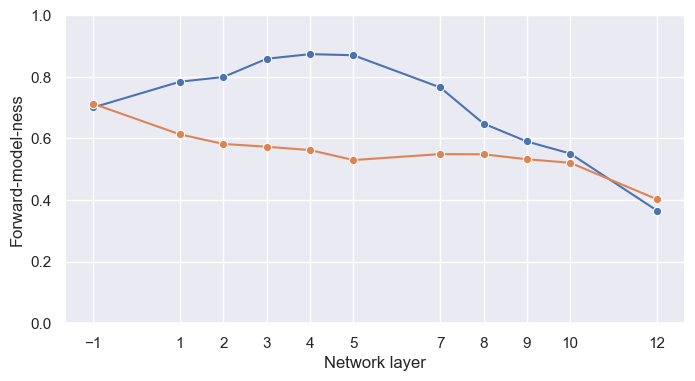

In [63]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=data, x="plot_xcoord", y="test_r2",
             hue="condition", style="condition", legend=False, markers=["o", "o"], dashes=False)
plt.ylim(0, 1)
plt.ylabel("Forward-model-ness")
plt.xticks(layers_df.plot_xcoord)
plt.xlabel("Network layer")
plt.savefig("figures/delay_10_layers_obs_decoding_manual.svg", bbox_inches="tight")

# Imitation performance

In [67]:
data = pd.read_csv("../forward-loss-vs-architecture/data.csv")
data = data[data.condition.isin(["forward_model", "pg_forward_model"])]

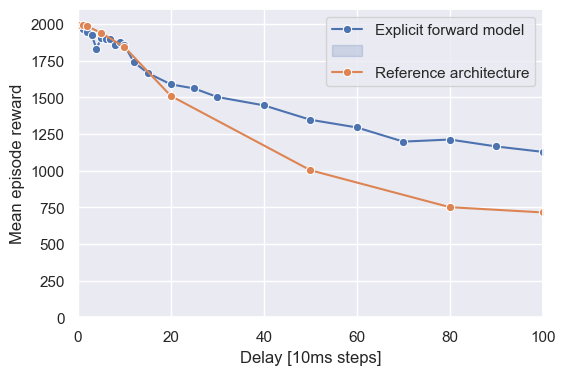

In [ ]:
plt.figure(figsize=(6, 4))
sns.lineplot(data=data, x="delay_k", y="episode_reward_mean", hue="condition", style="condition",
             dashes=False, markers=["o", "o"])
plt.ylabel("Mean episode reward")
plt.xlabel("Delay [10ms steps]")
plt.xlim(0, 100)
plt.ylim(0, 2100)
plt.legend(["Explicit forward model", None, "Architecture only"], )
plt.savefig("figures/")

In [70]:
data.columns

Index(['wandb_id', 'wandb_name', 'wandb_project', 'state', 'git_commit',
       'tags', 'notes', 'env', 'delay_k', 'efference_length', 'seed',
       'fm_loss_weight', 'detach_prediction', 'latent_size', 'kl_weight',
       'body_target_frame', 'enc_hidden_sizes', 'dec_hidden_sizes',
       'critic_hidden_sizes', 'episode_reward/mean', 'episode_reward/std',
       'eval/episode_reward/mean', 'eval/episode_reward/std',
       'net/3/action/1/fm_pred_mse/p25', 'net/3/action/1/fm_pred_mse/p50',
       'net/3/action/1/fm_pred_mse/p75',
       'eval/net/3/action/1/fm_pred_mse/mean',
       'eval/net/3/action/1/fm_pred_mse/std', 'actual_step', 'condition',
       'git_short', 'episode_reward_mean', 'fm_mse_p50', 'fm_mse_p25',
       'fm_mse_p75', 'fm_mse_eval_mean'],
      dtype='object')